In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path

In [25]:
from mapa_ciencia_unc import data_handlers

## Read enrollments

In [33]:
MERGED_DATA_DIRPATH = Path('../../shared-volume/sampled_csv/')
PUBLIC_COLS_ENROLLMENT = ['name', 'gender', 'academic_unit', 'last_project_title']

In [34]:
df_enrollment = pd.read_json(MERGED_DATA_DIRPATH / 'enrollment.json', lines=True)

In [35]:
df_enrollment[PUBLIC_COLS_ENROLLMENT].sample(10)

,name,gender,academic_unit,last_project_title
37,Melisa,Mujer,"FCA, FCM",None
110,ANA GUADALUPE,Mujer,FCA,"CARACTERIZACIÓN, DOMESTICACIÓN Y CULTIVO DE ES..."
81,Nicolas Santiago,Hombre,Otros,None
2,Consuelo,Mujer,FCS,"Políticas del cuerpo ficción: vida, tecnología..."
51,Gustavo,Hombre,FaMAF,Modelado de Sistemas Biológicos Complejos
24,María Celeste,Mujer,FCE,Las mujeres en la industria manufacturera arge...
112,Pablo Sebastian,Hombre,FCS,Patrones de Incorporación Educativa de Migrant...
89,Guillermo,Hombre,FFyH,La dimensión performativa de la representación...
85,Alejandro Rodrigo,Hombre,FA,La forma en movimiento. Experiencias sobre la ...
131,Miriam Gladys,Mujer,FAUD,None


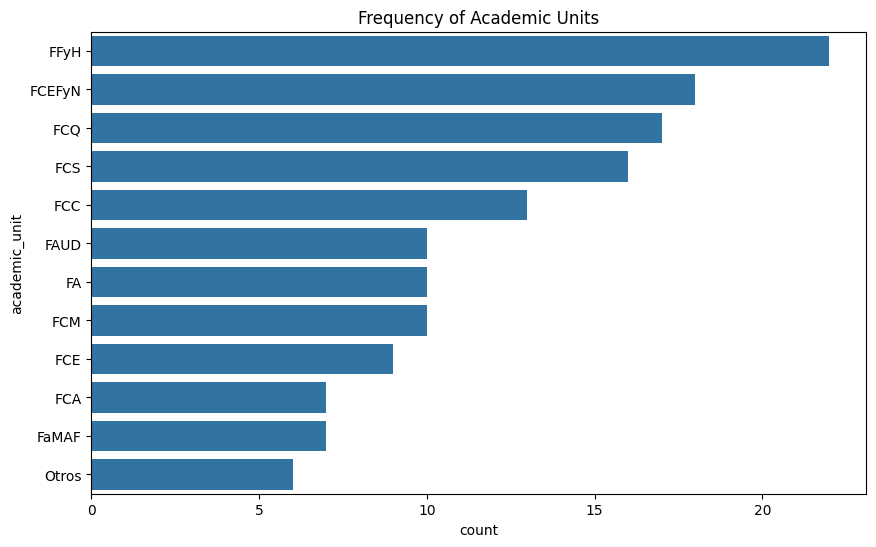

In [29]:
# explode comma-separated values into separate rows
df = df_enrollment.assign(
    academic_unit=df_enrollment["academic_unit"].str.split(",")
).explode("academic_unit")

# clean whitespace
df["academic_unit"] = df["academic_unit"].str.strip()

# count frequencies
counts = df["academic_unit"].value_counts().reset_index()
counts.columns = ["academic_unit", "count"]

# plot
plt.figure(figsize=(10,6))
sns.barplot(data=counts, x="count", y="academic_unit")
plt.title("Frequency of Academic Units")
plt.show()

## Read publications

In [39]:
df_articles = pd.read_json(MERGED_DATA_DIRPATH / 'articles.json', lines=True)
PUBLIC_COLS_ARTICLES = ['autores', 'titulo', 'resumen']

In [38]:
df_articles.sample(10)

,autores,titulo,resumen,cuit,lugar_de_trabajo
76,"MENESES, FERNANDO; GUTIERREZ, FABIANA A.; URRE...",Nickel nanobrush platform for a magnetic field...,single-step electrochemical procedure to synth...,20355263771,GRUPO DE CS.DE MATERIALES
1651,"TAVERA BUSSO, IVAN; SILVA GUILLERMO; CARRERAS, H.",Organic compounds present in airborne particle...,uspended particulate matter (SPM) trigger the ...,23202681484,FACULTAD DE CIENCIAS EXACTAS FISICAS Y NATURALES
690,H. M. VILLULLAS; V. BRUNETTI; M. LÓPEZ TEIJELO,The hanging meniscus rotating disk part 4. App...,It has been shown in previous papers that the ...,27223703165,DEPARTAMENTO DE FISICOQUIMICA
208,"ECHAVARRIA, CORINA",PROCESOS DE CONSTRUCCIÓN INTERACTORAL DE CONOC...,l presente trabajo forma parte de un proceso e...,27222248812,FACULTAD DE CIENCIAS SOCIALES
1460,"BRANCA, AYELÉN",La categoría de imperialismo en las formulacio...,"n el presente trabajo, se reconstruye el abord...",27361243388,CENTRO DE INVESTIGACIONES MARIA SALEME BURNICHON
831,LENNART WIRTHMUELLER; SHUTA ASAI; GHANASYAM RA...,Arabidopsis Downy Mildew effector HaRxL106 sup...,he oomycete pathogen Hyaloperonospora arabidop...,27258613568,DEPARTAMENTO DE QUIMICA BIOLOGICA
1749,DIEGO ANTONIO BELTRAMONE,POSTA web platform - Open Source Projects of A...,espite the important role that assistive techn...,20223712534,FACULTAD DE CIENCIAS EXACTAS FISICAS Y NATURALES
1733,"GUERRA, LUCÍA; MARTINI, MATEO A.; VOGEL, HENDR...",Microstratigraphy and palaeoenvironmental impl...,igh-mountain lake records in semiarid foreland...,20303464892,CENTRO DE INVESTIGACIONES EN CIENCIAS DE LA TI...
1386,"SORÁ, GUSTAVO",Edición y política. Guerra fría en la cultura ...,a publicación de Los hijos de Sánchez por el F...,20182832848,FACULTAD DE FILOSOFIA Y HUMANIDADES
1290,"CEPEDA BURGHINI, ROMINA; LUQUE, LIZET; RAMIREZ...",MONITOREO DE HONGOS AMBIENTALES EN LABORATORIO...,os hongos son organismos cosmopolitas que pued...,27248846815,FACULTAD DE FILOSOFIA Y HUMANIDADES


## Read Projects

In [42]:
df_projects = pd.read_json(MERGED_DATA_DIRPATH / 'projects.json', lines=True)
PUBLIC_COLS_PROJECTS = ['titulo_proyecto', 'resumen_proyecto', 'nombre', 'fecha_alta']

In [43]:
df_projects[PUBLIC_COLS_PROJECTS].sample(10)

,titulo_proyecto,resumen_proyecto,nombre,fecha_alta
219,Nanoestructuras para la prevención y el tratam...,Evaluar la potencialidad de nanoestructuras co...,ALEJANDRO MANUEL,2017-11-23 15:04:56
177,Narrativas en (con)versación: la comunicación ...,En este proyecto de investigación nos proponem...,FLORENCIA,2023-07-24 10:58:31
105,Continuidad y discontinuidad del PIC psicoanal...,Se desarrollará una pormenorizada indagación s...,MARIA EUGENIA,2014-02-13 13:57:46
719,Trabajo e ingresos en la configuración actual ...,"Bajo la modalidad ?Problemáticas Sociales?, la...",MARIANA,2023-10-27 09:12:43
590,RESTOS HUMANOS DEL MUSEO DE ANTROPOLOGÍA (FFYH...,Se propone la puesta en valor y el estudio de ...,MARIANA,2018-05-28 15:51:07
233,Trabajo e ingresos en la configuración actual ...,"Bajo la modalidad ?Problemáticas Sociales?, la...",AYELÉN ELIANA,2023-10-27 09:12:43
401,Innovación y transferencia en sistemas agrícol...,"Las secuencias de cultivos que incluyan maíz, ...",PABLO ARIEL,2022-03-16 13:49:59
631,CARACTERIZACIÓN DE POBLACIONES DE ESPECIES ARO...,En Argentina se utilizan con fines comerciales...,ANA GUADALUPE,2014-02-25 15:46:34
116,OBSERVATORIO VIRTUAL DE ARQUITECTURA CONTEMPOR...,Este proyecto se concibe como un trabajo de in...,MARIA REBECA,2015-12-04 18:50:04
75,Atención Primaria de la Salud: evaluación de u...,En las enfermedades crónicas no transmisibles ...,PATRICIA FABIANA,2018-06-05 13:20:56
